# ARIMA Visualization

## Install libraries

In [1]:
# !pip install -r ../../requirements.txt

## Import libraries

In [2]:
import os
import sys
import pandas as pd

# go one level up from where the notebook is running
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), "..")))

from logger.logger import Logger
from visualizer.visualizer import Visualizer
from model.arima_model import ArimaModel
from utils.constants import *
from utils.enums import *
from dtos.tabular_database_driver_dtos.tabular_database_driver_dtos import *

## Helper functions

In [3]:
def auto_convert(df: pd.DataFrame) -> pd.DataFrame:
    for col in df.columns:
        # Dates
        if "date" in col.lower():
            df[col] = pd.to_datetime(df[col], errors="coerce")

        # Codes
        elif "code" in col.lower():
            df[col] = df[col].astype("string")

        # Market IDs
        elif "market_id" in col.lower():
            df[col] = pd.to_numeric(df[col], errors="coerce").astype("Int64")

        # OHLC
        elif col.lower() in ["open", "high", "low", "close"]:
            df[col] = pd.to_numeric(df[col], errors="coerce").astype(float)

        # Volume
        elif "volume" in col.lower():
            df[col] = pd.to_numeric(df[col], errors="coerce").astype("Int64")

    return df

## Initialize the Logger

In [4]:
my_logger = Logger(file_name=ARIMA_VISUALIZATION_LOG_FILE_BASE)

## Initialize the Visualizer

In [5]:
my_visualizer = Visualizer(logger=my_logger)

## Initialize the ArimaModel

In [6]:
arima_model = ArimaModel(logger=my_logger)

## Parameters

In [7]:
stock_code = "GAS"
value_column_name = "close"

## Load data

In [8]:
arima_model.connect_to_database(database_name=os.getenv("BRONZE_POSTGRES_DATABASE"))

<DatabaseExecutionStatus.SUCCESS: 'success'>

In [9]:
df = arima_model.select(
    schema_name="enterprise",
    table_name="daily_price",
    conditions=[
        Condition(
            column="code",
            operator=SqlOperator.EQUAL_TO,
            value=stock_code,
            data_type=DataType.VARCHAR,
        )
    ],
    order_by=["date"],
)
df = auto_convert(df)
df

,date,code,market_id,open,high,low,close,volume
0,2012-05-21,GAS,1,15.9655,17.7347,15.9655,17.6935,2502080
1,2012-05-22,GAS,1,18.5545,18.5545,18.3388,18.5566,1934550
2,2012-05-23,GAS,1,18.5114,18.5545,17.6484,17.6503,1055780
3,2012-05-24,GAS,1,16.8285,17.2600,16.7854,16.7872,1009380
4,2012-05-25,GAS,1,16.7854,17.1737,16.0087,16.8304,877260
...,...,...,...,...,...,...,...,...
3295,2025-08-06,GAS,1,67.8000,69.3000,67.8000,69.3000,1299600
3296,2025-08-07,GAS,1,69.9000,69.9000,68.6000,69.1000,977200
3297,2025-08-08,GAS,1,69.4000,70.9000,69.0000,70.2000,2210600
3298,2025-08-11,GAS,1,70.3000,71.2000,70.1000,70.4000,1228900


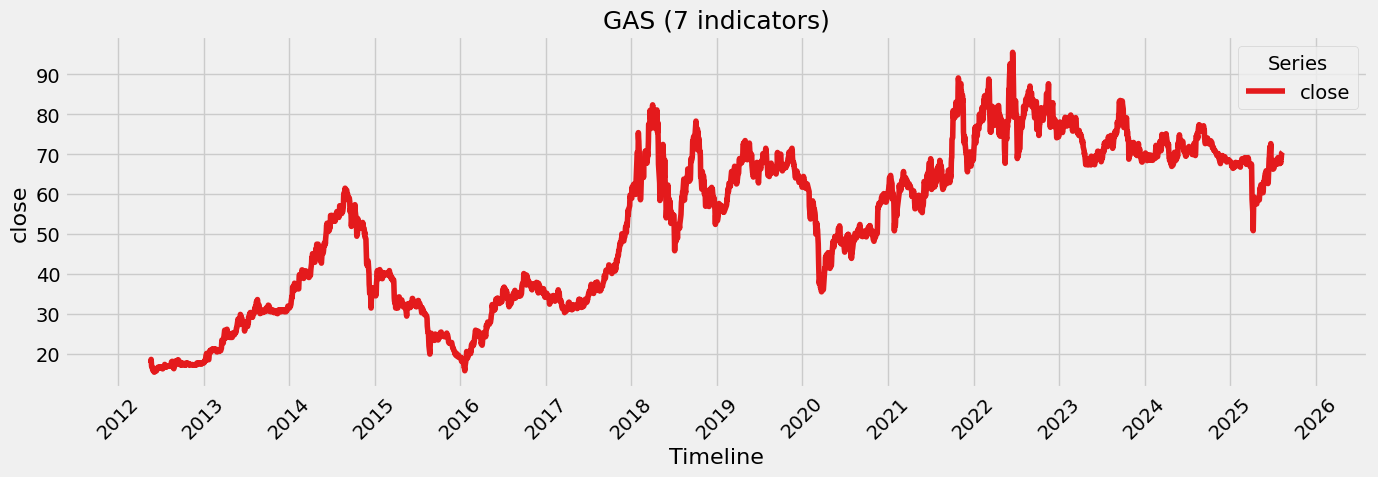

In [11]:
my_visualizer.plot_lines_chart(
    df,
    x_column="date",
    y_columns=[value_column_name],
    title=stock_code,
    y_axis_title=value_column_name,
    y_unit="",
    prefix_figure_name=stock_code,
    marker=None,
)

## Divide data into train and test

In [12]:
train = df.iloc[: len(df) - 90]
test = df.iloc[len(df) - 90 :]

In [13]:
train

,date,code,market_id,open,high,low,close,volume
0,2012-05-21,GAS,1,15.9655,17.7347,15.9655,17.6935,2502080
1,2012-05-22,GAS,1,18.5545,18.5545,18.3388,18.5566,1934550
2,2012-05-23,GAS,1,18.5114,18.5545,17.6484,17.6503,1055780
3,2012-05-24,GAS,1,16.8285,17.2600,16.7854,16.7872,1009380
4,2012-05-25,GAS,1,16.7854,17.1737,16.0087,16.8304,877260
...,...,...,...,...,...,...,...,...
3205,2025-03-27,GAS,1,67.6000,68.0000,67.1000,67.2000,426500
3206,2025-03-28,GAS,1,67.4000,67.4000,66.8000,66.8000,771800
3207,2025-03-31,GAS,1,66.8000,66.8000,66.0000,66.8000,727900
3208,2025-04-01,GAS,1,66.9000,67.8000,66.7000,67.5000,870900


In [14]:
test

,date,code,market_id,open,high,low,close,volume
3210,2025-04-03,GAS,1,63.5,65.4,62.5,62.5,2014500
3211,2025-04-04,GAS,1,58.2,60.8,58.2,58.7,2745000
3212,2025-04-08,GAS,1,56.0,56.3,54.6,54.6,2632500
3213,2025-04-09,GAS,1,50.8,56.0,50.8,50.8,2768600
3214,2025-04-10,GAS,1,54.3,54.3,54.3,54.3,57500
...,...,...,...,...,...,...,...,...
3295,2025-08-06,GAS,1,67.8,69.3,67.8,69.3,1299600
3296,2025-08-07,GAS,1,69.9,69.9,68.6,69.1,977200
3297,2025-08-08,GAS,1,69.4,70.9,69.0,70.2,2210600
3298,2025-08-11,GAS,1,70.3,71.2,70.1,70.4,1228900


## Fit the model

In [15]:
arima_model.fit(
    train_df=train,
    test_df=test,
    time_column_name="date",
    value_column_name="close",
    max_p=10,
    max_q=10,
)

ARIMA fit parameters -> start_p=1, start_q=1, max_p=10, max_q=10, m=1, d=1, seasonal=True, start_P=1, start_Q=1, D=0


Trying ARIMA candidate: : 1it [00:00,  6.31it/s]

Performing stepwise search to minimize aic


Trying ARIMA candidate: : 11it [00:00, 18.66it/s]

 ARIMA(1,1,1)(0,0,0)[0] intercept   : AIC=10047.012, Time=0.53 sec
 ARIMA(0,1,0)(0,0,0)[0] intercept   : AIC=10051.772, Time=0.03 sec
 ARIMA(1,1,0)(0,0,0)[0] intercept   : AIC=10051.502, Time=0.10 sec


...

 ARIMA(2,1,1)(0,0,0)[0]             : AIC=10046.518, Time=0.33 sec


Trying ARIMA candidate: : 123it [00:05, 47.18it/s]

 ARIMA(1,1,2)(0,0,0)[0]             : AIC=10046.511, Time=0.25 sec
 ARIMA(0,1,2)(0,0,0)[0]             : AIC=10046.449, Time=0.13 sec
 ARIMA(2,1,0)(0,0,0)[0]             : AIC=10046.987, Time=0.08 sec


Trying ARIMA candidate: : 150it [00:05, 25.65it/s]


 ARIMA(2,1,2)(0,0,0)[0]             : AIC=10047.818, Time=0.55 sec

Best model:  ARIMA(1,1,1)(0,0,0)[0]          
Total fit time: 5.839 seconds


In [26]:
best_order = arima_model.get_best_order()
best_order

(1, 1, 1)

## Rolling Forecast (Expanding)

In [19]:
preds_expanding = arima_model.rolling_forecast()

In [20]:
preds_expanding

,ds,actual_y,test_pred
0,2025-04-03,62.5,67.516687
1,2025-04-04,58.7,62.296853
2,2025-04-08,54.6,58.701511
3,2025-04-09,50.8,54.442212
4,2025-04-10,54.3,50.768746
...,...,...,...
85,2025-08-06,69.3,67.790255
86,2025-08-07,69.1,69.364367
87,2025-08-08,70.2,69.045861
88,2025-08-11,70.4,70.281147


## Rolling Forecast (Sliding)

In [43]:
preds_sliding = arima_model.rolling_forecast(mode="sliding", window_size=365)

d:\DATA SCIENCE\GIT\master-thesis\mt_env\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
d:\DATA SCIENCE\GIT\master-thesis\mt_env\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
d:\DATA SCIENCE\GIT\master-thesis\mt_env\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
d:\DATA SCIENCE\GIT\master-thesis\mt_env\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: Va

In [44]:
preds_sliding

,ds,actual_y,test_pred
0,2025-04-03,62.5,67.487363
1,2025-04-04,58.7,62.604479
2,2025-04-08,54.6,58.684396
3,2025-04-09,50.8,54.690038
4,2025-04-10,54.3,50.796422
...,...,...,...
85,2025-08-06,69.3,67.798748
86,2025-08-07,69.1,69.272856
87,2025-08-08,70.2,69.126364
88,2025-08-11,70.4,70.157374


## Plot the rolling forecasts (Expanding and Sliding)

Figure saved to: ../../charts/arima\GAS_1_1_1.png


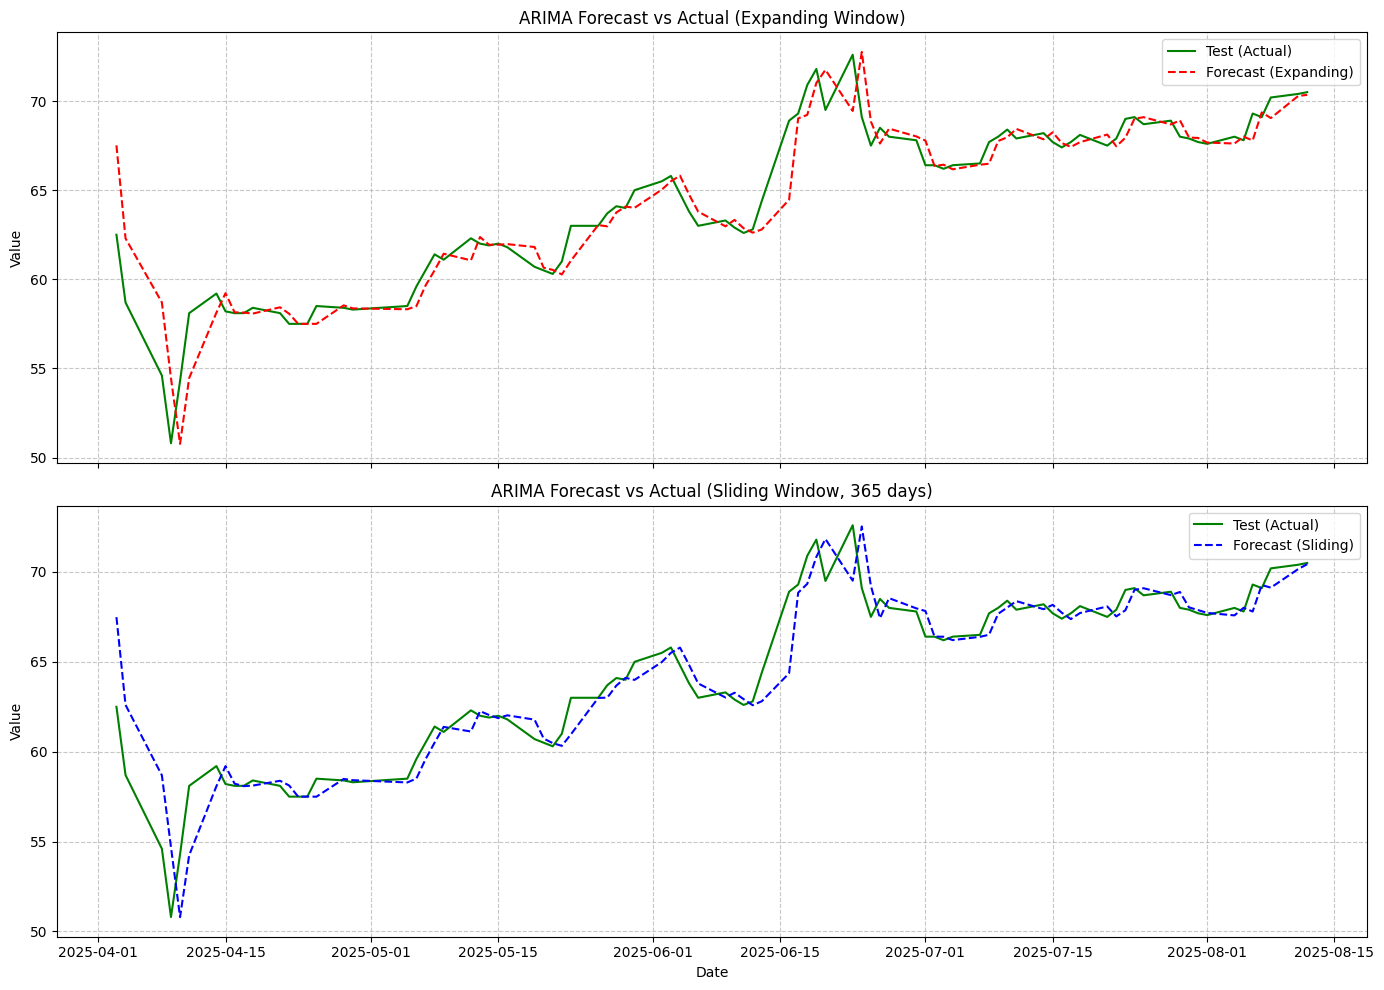

In [46]:
arima_model.plot_rolling_forecast(
    preds_expanding, preds_sliding, file_name=f"{stock_code}"
)